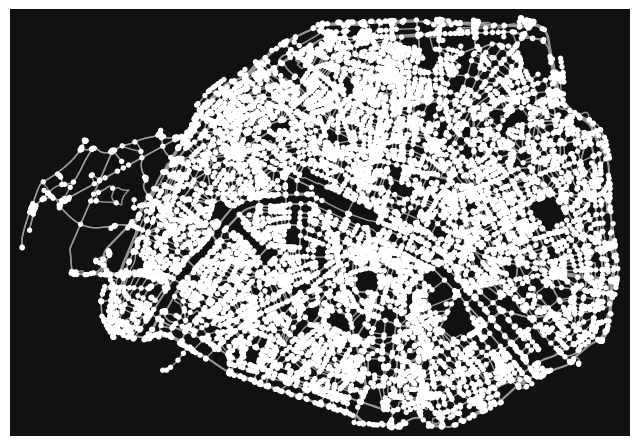

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [1]:
import osmnx as ox

# Télécharger le réseau routier pour une ville ou une région spécifique
place_name = "Paris, France"
graph_Paris = ox.graph_from_place(place_name, network_type='drive')

# Optionnel : simplifier le graphe pour éliminer les nœuds superflus
ox.plot_graph(graph_Paris)

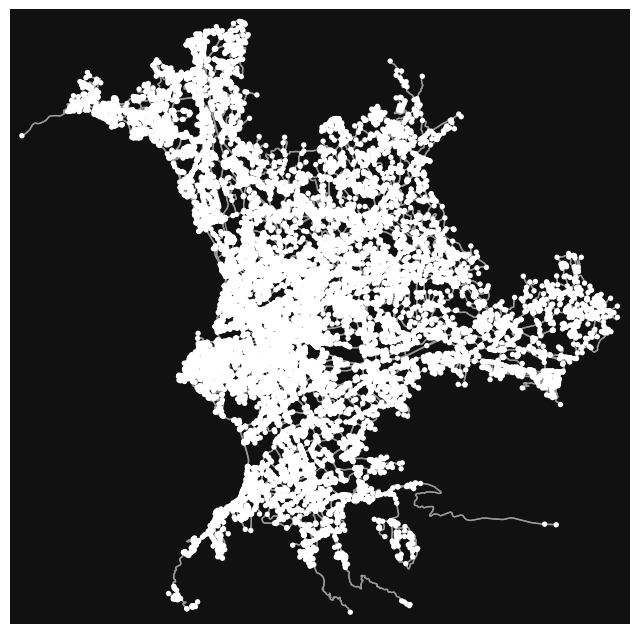

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [2]:
import osmnx as ox

# Télécharger le réseau routier pour une ville ou une région spécifique
place_name = "Marseille, France"
graph_Marseille = ox.graph_from_place(place_name, network_type='drive')

# Optionnel : simplifier le graphe pour éliminer les nœuds superflus
ox.plot_graph(graph_Marseille)

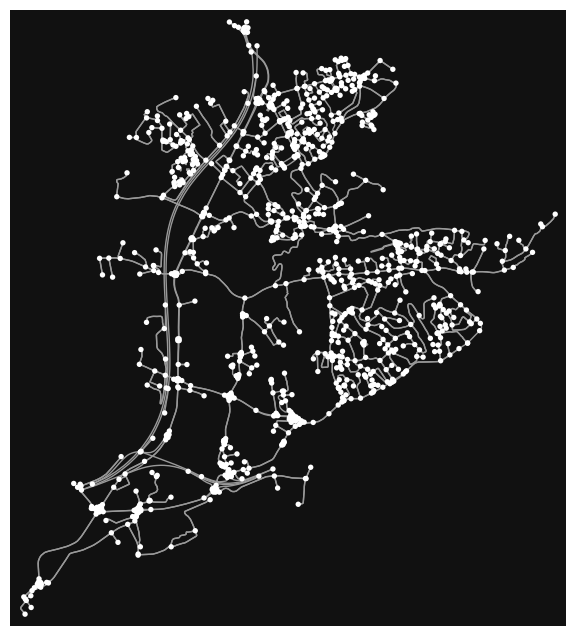

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [1]:
import osmnx as ox

# Télécharger le réseau routier pour une ville ou une région spécifique
place_name = "Bouc Bel Air, France"
graph_Bouc_Bel_Air = ox.graph_from_place(place_name, network_type='drive')

# Optionnel : simplifier le graphe pour éliminer les nœuds superflus
ox.plot_graph(graph_Bouc_Bel_Air)


Permer de téléchager la carte routiére de la région PACA

In [2]:
import osmnx as ox

place_name = "Provence-Alpes-Côte d'Azur, France"

graph_PACA = ox.graph_from_place(place_name, network_type='drive')

ox.save_graphml(graph_PACA, filepath="PACA_graph.graphml")

C:\Users\flofl\AppData\Local\Programs\Python\Python312\Lib\site-packages\osmnx\_overpass.py:254: UserWarning: This area is 17 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x00000271D9622CF0>>
Traceback (most recent call last):
  File "C:\Users\flofl\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel\ipkernel.py", line 790, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
                                                 ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\flofl\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1533, in enumerate
    def enumerate():
    
KeyboardInterrupt: 

KeyboardInterrupt



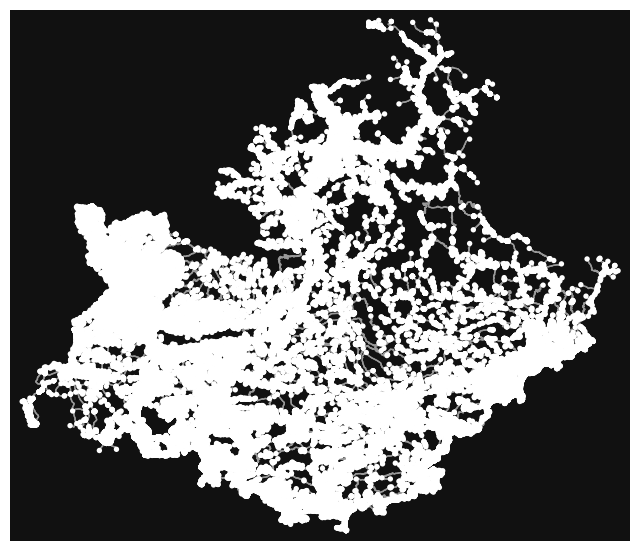

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:
import matplotlib.pyplot as plt
graph = ox.load_graphml(filepath="PACA_graph.graphml")
ox.plot_graph(graph)

In [2]:
import random

graphe_utiliser = graph_Bouc_Bel_Air


# 2. Choisir un nœud aléatoire*
point_de_depart = random.choice(list(graphe_utiliser.nodes))
point_arriver = random.choice(list(graphe_utiliser.nodes))
print(f"Nœud sélectionné :{point_de_depart} {point_arriver}")
max_steps = 30
#neighbors_point_de_depart = graphe_utiliser.neighbors(point_de_depart)
# 3. Obtenir les voisins directs (points adjacents)
voisins = list(graphe_utiliser.neighbors(point_arriver))
#print(f"Voisins du nœud {point_arriver} : {voisins}")

# 4. Afficher les distances (et autres données) entre le nœud et ses voisins
#for voisin in voisins:
#    edge_data = graphe_utiliser.get_edge_data(point_arriver, voisin)
#    print(f"Arête entre {point_arriver} et {voisin} : {edge_data}")
    
info_trajet = graphe_utiliser.get_edge_data(point_de_depart,point_arriver)
print(info_trajet)    


Nœud sélectionné :1847420450 849601776
None


Algorithme génétique pour la résolution du problème du voyageur de commerce
Introduction
Un algorithme génétique est un algorithme évolutionniste utilisé pour résoudre des problèmes d’optimisation de manière approchée, lorsque le calcul exact est trop coûteux. Il utilise la notion de sélection naturelle (inspiré de la théorie de l’évolution de Darwin) et l’applique à un ensemble (une population) de solutions possibles du problème d’optimisation.

De façon générale un algorithme génétique pour la résolution d’un problème d’optimisation fonctionne sur le principe suivant.

On construit un ensemble initial d’individus (aussi appelés chromosomes) qui sont constitué de gènes. Ces individus représentent chacun une solution possible du problème d’optimisation.
Puis ont itère jusqu’à ce qu’un critère d’arrêt soit atteint (si aucune modification bénéfique n’apparaît pendant un certain temps par exemple)

On choisit parmi ces individus un ensemble de parents qui vont se reproduire.
Les couples de parents se reproduisent et donnent naissance à deux enfants qui sont un mélange de leurs gènes (crossover).
Les enfants peuvent subir des mutations aléatoires de leurs gènes (mutation).
Puis on sélectionne parmi la population globale (parents et enfants) un ensemble d’individus qui survivront selon un critère d’adaptabilité (fitness).
Chacune des étapes ci-dessus peut se réaliser de différentes manières. Nous allons en proposer une dans ce qui suit.

In [19]:
curent_node = point_de_depart
neighbor_curent_node = graphe_utiliser.neighbors(curent_node)
print(neighbor_curent_node)

In [3]:
def generate_random_path(graphe, point_départ, point_arriver, max_steps=30):
    path = [point_départ]
    current_node = point_départ

    for _ in range(max_steps):
        neighbors = [n for n in graphe.neighbors(current_node) if n not in path]
        if not neighbors:
            break  # plus de voisins disponibles
        next_node = random.choice(neighbors)
        path.append(next_node)
        current_node = next_node
        if current_node == point_arriver:
            break

    return path
    
def generate_population(number_of_pop = 1000):
    population = []
    for i in range(number_of_pop):
        path = generate_random_path(graphe_utiliser, point_de_depart, point_arriver, max_steps)
        population.append(path)
    return population

population = generate_population()
print(population)

[[1847420450, 1493253098, 3756415470, 3755920327], [1847420450, 1493253098, 3756415470, 892968001, 3756415472, 3756415471, 1493253217], [1847420450, 1493253098, 494035040, 1493253043], [1847420450, 1493253098, 3756415470, 892968001, 3756415472, 892968007], [1847420450, 1493253098, 494035040, 1493253043], [1847420450, 1493253098, 3756415470, 3755920327], [1847420450, 1493253098, 494035040, 1493253043], [1847420450, 1493253098, 494035040, 1493253043], [1847420450, 1493253098, 494035040, 3756415474, 494035044, 1493253027, 1493253039, 1493253069], [1847420450, 1493253098, 3756415470, 3755920327], [1847420450, 1493253098, 3756415470, 892968001, 3756415472, 892968007], [1847420450, 1493253098, 494035040, 1493253043], [1847420450, 1493253098, 3756415470, 892968001, 3756415472, 3756415471, 1493253217], [1847420450, 1493253098, 494035040, 1493253043], [1847420450, 1493253098, 494035040, 3756415474, 3756415473], [1847420450, 1493253098, 3756415470, 892968001, 3756415471, 3756415472, 892968007], 

In [4]:
def distance_path(graphe,path):
    distance = 0
    for i in range(len(path) - 1):
        data_node = graphe.get_edge_data(path[i], path[i + 1])
        distance  += data_node[0].get("length", 1)
    return distance

In [5]:
from math import dist

def fitness_function(graph, path, end_node):
    total_length = distance_path(graph, path)
    x1, y1 = graph.nodes[path[-1]]['x'], graph.nodes[path[-1]]['y']
    x2, y2 = graph.nodes[end_node]['x'], graph.nodes[end_node]['y']
    distance_to_goal = dist((x1, y1), (x2, y2))

    if path[-1] == end_node:
        return 10000 / (1 + total_length)  # bonus énorme pour avoir atteint l'objectif
    else:
        return 1 / (1 + distance_to_goal)  # sinon, jugé uniquement sur la proximité


In [6]:
fitness_scores = []  # Liste de tuples (individu, fitness)

for individu in population:
    try:
        score = fitness_function(graphe_utiliser, individu, point_arriver)
        fitness_scores.append((individu, score))
    except Exception as e:
        print(f"Erreur pour un individu : {e}")

# Trier du plus fort au plus faible
fitness_scores_sorted = sorted(fitness_scores, key=lambda x: x[1], reverse=True)

# Afficher le top 5
print("\nTop 5 individus les plus adaptés :")
for i, (path, score) in enumerate(fitness_scores_sorted[:5]):
    print(f"#{i+1} | Score: {score:.4f} | Longueur du chemin : {len(path)}")



Top 5 individus les plus adaptés :
#1 | Score: 4.8520 | Longueur du chemin : 17
#2 | Score: 0.9981 | Longueur du chemin : 22
#3 | Score: 0.9977 | Longueur du chemin : 19
#4 | Score: 0.9960 | Longueur du chemin : 6
#5 | Score: 0.9960 | Longueur du chemin : 6


1. Générer population
2. Évaluer fitness
3. Sélection (les meilleurs + les chanceux)
4. Croisement (crossover)
5. Mutation (petit chaos pour explorer)
6. Nouvelle génération → recommencer


🧪 1. MUTATION

🎯 Objectif : Modifier un chemin légèrement pour introduire de la diversité.

📌 Idées de mutation :

    1 Remplacer un nœud par l’un de ses voisins

    2 Supprimer ou insérer un nœud aléatoire

    3 Recalculer la fin d’un chemin aléatoire à partir d’un nœud du milieu

In [7]:
import random
def funtion_mutation(population, graphe_utiliser, point_arriver, mutation_rate=0.2, max_steps=30):
    mutated_population = list()  
    for gene in population:
        if random.random() > mutation_rate:
            mutated_population.append(gene)
            continue
        
        mutation_point = random.randint(1, min(len(gene), max_steps))
        path_head = gene[:mutation_point]
        last_node = path_head[-1]
        
        path_tail = generate_random_path(graphe_utiliser, last_node, point_arriver, max_steps - mutation_point)
        
        mutated_path = path_head + path_tail[1:]  # on évite de répéter le nœud de mutation
        mutated_population.append(mutated_path)
        
    return mutated_population


mutation = funtion_mutation(population, graphe_utiliser, point_arriver, mutation_rate=0.3, max_steps=30)


print(mutation)

[[1847420450, 1493253098, 3756415470, 3755920327], [1847420450, 1493253098, 3756415470, 892968001, 3756415472, 3756415471, 1493253217], [1847420450, 1493253098, 3756415470, 3755920327], [1847420450, 1493253098, 3756415470, 892968001, 3756415472, 892968007], [1847420450, 1493253098, 494035040, 1493253043], [1847420450, 1493253098, 3756415470, 3755920327], [1847420450, 1493253098, 3756415470, 3755920327], [1847420450, 1493253098, 494035040, 1493253043], [1847420450, 1493253098, 494035040, 3756415474, 494035044, 3756415474, 494035040, 1493253098, 1847420450], [1847420450, 1493253098, 3756415470, 3755920327], [1847420450, 1493253098, 3756415470, 892968001, 3756415472, 892968007], [1847420450, 1493253098, 494035040, 1493253043, 494035040, 3756415474, 494035044, 1493253027, 1493253039, 1493253069], [1847420450, 1493253098, 3756415470, 892968001, 3756415472, 3756415471, 1493253217], [1847420450, 1493253098, 494035040, 1493253043], [1847420450, 1493253098, 3756415470, 3755920327], [1847420450,

In [8]:
def function_selection(population, graph, end_node, elite_ratio=0.1, random_ratio=0.4):
    scored_population = [(ind, fitness_function(graph, ind, end_node)) for ind in population]
    scored_population.sort(key=lambda x: x[1], reverse=True)

    elite_count = int(len(population) * elite_ratio)
    random_count = int(len(population) * random_ratio)

    elites = [ind for ind, _ in scored_population[:elite_count]]
    random_selected = random.sample([ind for ind, _ in scored_population[elite_count:]], random_count)

    selected = elites + random_selected
    return selected


In [14]:
def function_crossover(parent1, parent2):
    # Trouver les nœuds communs entre les deux parents
    common_nodes = list(set(parent1) & set(parent2))

    # Pas de croisement possible si moins de 3 nœuds en commun
    if len(common_nodes) <= 2:
        return parent1

    # On sécurise le choix d’un point de croisement entre 1 et len-2
    internal_common_nodes = common_nodes[1:-1]
    if not internal_common_nodes:
        return parent1

    crossover_node = random.choice(internal_common_nodes)

    i1 = parent1.index(crossover_node)
    i2 = parent2.index(crossover_node)

    # Fusion : début de parent1 + fin de parent2
    child = parent1[:i1] + parent2[i2:]
    return child


In [10]:
def function_next_generation(population, graph, end_node, max_steps=30, mutation_rate=0.2):
    selected = function_selection(population, graph, end_node)

    new_population = []
    while len(new_population) < len(population):
        parent1, parent2 = random.sample(selected, 2)
        child = function_crossover(parent1, parent2)

        # Mutation aléatoire
        if random.random() < mutation_rate:
            mutation_point = random.randint(1, len(child) - 2)
            child = child[:mutation_point]
            current = child[-1]
            visited = set(child)
            for i in range(max_steps - len(child)):
                neighbors = [n for n in graph.neighbors(current) if n not in visited]
                if not neighbors:
                    break
                next_node = random.choice(neighbors)
                child.append(next_node)
                visited.add(next_node)
                current = next_node
                if current == end_node:
                    break

        new_population.append(child)

    return new_population


In [20]:
import heapq


def Algorithme_Dijkstra(graphe,noeud_départ,noeud_arriver):
    distances = {n: float('inf') for n in graphe.nodes}
    distances[noeud_départ] = 0
    previous = {}
    visited = set()
    queue = [(0, noeud_départ)]
    
    while queue:
        dist_actuelle, noeud_actuel = heapq.heappop(queue)
        
        if noeud_actuel in visited:
            continue
            
        visited.add(noeud_actuel)
        
        if noeud_actuel == noeud_arriver:
            break
            
        for voisin in graphe.neighbors(noeud_actuel):
            if voisin in visited:
                continue
                
            edge_data = graphe.get_edge_data(noeud_actuel, voisin)
            min_length = min(info.get("length", float('inf')) for info in edge_data.values())
            nouvelle_distance = dist_actuelle + min_length
            
            if nouvelle_distance < distances[voisin]:
                distances[voisin] = nouvelle_distance
                previous[voisin] = noeud_actuel
                heapq.heappush(queue, (nouvelle_distance, voisin))
                
    chemin = []
    noeud = noeud_arriver
    while noeud in previous:
        chemin.insert(0, noeud)
        noeud = previous[noeud]
    chemin.insert(0, noeud_départ)

    return chemin, distances[noeud_arriver]

algo_diji = Algorithme_Dijkstra(graphe_utiliser,point_de_depart,point_arriver)
print(algo_diji)

([1847420450, 1493253098, 494035040, 3756415474, 494035044, 9507207535, 1847420447, 1157598990, 267583870, 1157599002, 267584286, 256597968, 849601847, 849601806, 849601815, 849601776], 1429.5839999999998)


In [12]:
def run_genetic_algorithm(
    graph,
    start_node,
    end_node,
    population_size=1000,
    generations=50,
    max_steps=30,
    mutation_rate=0.2,
    elite_ratio=0.1,
    random_ratio=0.4
):
    # 1. Générer la population initiale
    population = generate_population()
    best_fitness_per_gen = []
    best_path = None
    best_score = 0

    for gen in range(generations):
        # 2. Évaluer la population
        scored = [(ind, fitness_function(graph, ind, end_node)) for ind in population]
        scored.sort(key=lambda x: x[1], reverse=True)

        # 3. Garder le meilleur
        if scored[0][1] > best_score:
            best_score = scored[0][1]
            best_path = scored[0][0]

        best_fitness_per_gen.append(scored[0][1])
        print(f"Génération {gen+1} | Meilleure fitness : {scored[0][1]:.4f} | Longueur : {len(scored[0][0])}")

        # 4. Générer la nouvelle génération
        population = function_next_generation(
            population,
            graph,
            end_node,
            max_steps=max_steps,
            mutation_rate=mutation_rate
        )

    print("\n=== Résultat final ===")
    print("Fitness finale :", best_score)
    print("Chemin trouvé :", best_path)

    return best_path, best_fitness_per_gen


In [16]:
best_path, scores = run_genetic_algorithm(
    graphe_utiliser,
    point_de_depart,
    point_arriver,
    population_size=1000,
    generations=50,
    max_steps=30
)
print(best_path)

Génération 1 | Meilleure fitness : 0.9960 | Longueur : 7
Génération 2 | Meilleure fitness : 0.9977 | Longueur : 17
Génération 3 | Meilleure fitness : 0.9977 | Longueur : 17
Génération 4 | Meilleure fitness : 0.9977 | Longueur : 17
Génération 5 | Meilleure fitness : 0.9981 | Longueur : 15
Génération 6 | Meilleure fitness : 0.9981 | Longueur : 15
Génération 7 | Meilleure fitness : 4.8520 | Longueur : 17
Génération 8 | Meilleure fitness : 0.9981 | Longueur : 23
Génération 9 | Meilleure fitness : 0.9981 | Longueur : 23
Génération 10 | Meilleure fitness : 3.8944 | Longueur : 24
Génération 11 | Meilleure fitness : 3.6386 | Longueur : 24
Génération 12 | Meilleure fitness : 3.8944 | Longueur : 24
Génération 13 | Meilleure fitness : 6.9902 | Longueur : 16
Génération 14 | Meilleure fitness : 6.9902 | Longueur : 16
Génération 15 | Meilleure fitness : 6.9902 | Longueur : 16
Génération 16 | Meilleure fitness : 6.9902 | Longueur : 16
Génération 17 | Meilleure fitness : 6.9902 | Longueur : 16
Générat

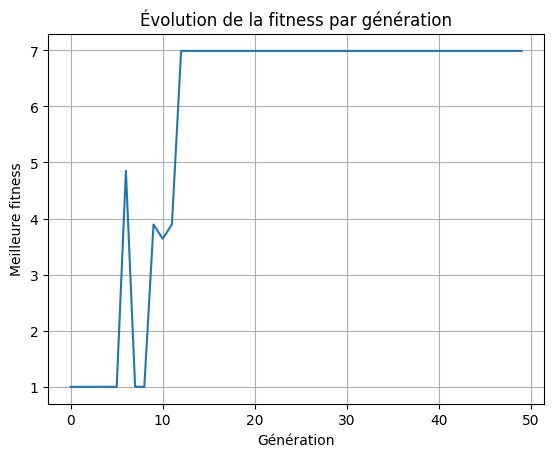

In [19]:
import matplotlib.pyplot as plt

plt.plot(scores)
plt.title("Évolution de la fitness par génération")
plt.xlabel("Génération")
plt.ylabel("Meilleure fitness")
plt.grid(True)
plt.show()


In [18]:
def Algorithme_Dijkstra2(graphe, noeud_départ, noeud_arriver):
    previous = {}
    visited = []
    distances =[]
    distances[noeud_départ] = 0
    distance_dic = {}
    noued_actuelle = noeud_départ
   # while noued_actuelle != noeud_arriver:
    for voisin in graphe.neighbors(noued_actuelle):
        data = graphe.get_edge_data(noued_actuelle, voisin)
        distances = [info.get("length", float('inf')) for info in data.values()]
        min_distance = min(distances)
        distance_dic[voisin] = min_distance

       
    voisin_plus_proche = min(distance_dic, key=distance_dic.get)
    
    noued_actuelle = voisin_plus_proche
    print(noued_actuelle)

    
    

algo_diji2 = Algorithme_Dijkstra2(graphe_utiliser,point_de_depart,point_arriver)

print(algo_diji2)

IndexError: list assignment index out of range